<center>
    <h1>
    Exploration - Étape 1
    </h1>
</center>

In [1]:
%%html

<!-- styles d'affichage -->
<style>
    .section_div {
        width:70%;
        height:1.5px;
        border:none;
        color:black;
        background-color:black;
        margin: auto;
        margin-top: 0px;
        margin-bottom: 0px;
    }

    .answer {
        color:blue;
    }

    .question {
        color:red;
    }

    .note {
        color:green;
        font-weight: bold;
    }
</style>

In [2]:
#
# assure le reload de src si modifications sont faite
#
%load_ext autoreload
%autoreload 2

In [3]:
#
# import utilitaires
#
%matplotlib inline

import librosa as rosa
import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

from pathlib import Path
from pprint import pprint
from tqdm.notebook import tqdm

In [4]:
#
# import package develope pour le projet
#
import ffury
from ffury.configs import (
    DatasetType,
    DEFAULT_CONFIG_FILE,
    load_config
)

def get_config():
    # creation config - on sait que DEFAULT_CONFIG_FILE est dans le repertoire parent
    config = Path(ffury.__file__).parents[2].joinpath(DEFAULT_CONFIG_FILE)
    return load_config(config)

config = get_config()

# load dataset BirdCLEF
raw_df = pd.read_csv(config.get_csv_filename(DatasetType.RAW))

In [5]:
print("Information sur le data:", config.dataset.data_description_url)

Information sur le data: https://www.kaggle.com/competitions/birdclef-2023/data


In [6]:
print("Dataset shape:", raw_df.shape)

print()

print("Types")
display(raw_df.dtypes.to_frame().T)

Dataset shape: (16941, 12)

Types


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,author,license,rating,url,filename
0,object,object,object,float64,float64,object,object,object,object,float64,object,object


In [7]:
#
# secondary_labels et type sont des listes
# valider que le parsing est bien ce qu'on pense
#
print("Type element 'secondary_labels':", type(raw_df.loc[0, "secondary_labels"]))
print("Type element 'type':", type(raw_df.loc[0, "type"]))

Type element 'secondary_labels': <class 'str'>
Type element 'type': <class 'str'>


<div class="answer">

On peut voir que la lecture du .csv n'est pas correcte. On devrait avoir une liste.

In [8]:
#
# corriger secondary_labels et type; ils sont des listes
#
if isinstance(raw_df.loc[0, "secondary_labels"], str):
    from ast import literal_eval

    raw_df["secondary_labels"] = raw_df["secondary_labels"].apply(literal_eval)
    raw_df["type"] = raw_df["type"].apply(literal_eval)

print()

print("Affichage succint")
display(raw_df.head())


Affichage succint


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,author,license,rating,url,filename
0,abethr1,[],[song],4.3906,38.2788,Turdus tephronotus,African Bare-eyed Thrush,Rolf A. de By,Creative Commons Attribution-NonCommercial-Sha...,4.0,https://www.xeno-canto.org/128013,abethr1/XC128013.ogg
1,abethr1,[],[call],-2.9524,38.2921,Turdus tephronotus,African Bare-eyed Thrush,James Bradley,Creative Commons Attribution-NonCommercial-Sha...,3.5,https://www.xeno-canto.org/363501,abethr1/XC363501.ogg
2,abethr1,[],[song],-2.9524,38.2921,Turdus tephronotus,African Bare-eyed Thrush,James Bradley,Creative Commons Attribution-NonCommercial-Sha...,3.5,https://www.xeno-canto.org/363502,abethr1/XC363502.ogg
3,abethr1,[],[song],-2.9524,38.2921,Turdus tephronotus,African Bare-eyed Thrush,James Bradley,Creative Commons Attribution-NonCommercial-Sha...,5.0,https://www.xeno-canto.org/363503,abethr1/XC363503.ogg
4,abethr1,[],"[call, song]",-2.9524,38.2921,Turdus tephronotus,African Bare-eyed Thrush,James Bradley,Creative Commons Attribution-NonCommercial-Sha...,4.5,https://www.xeno-canto.org/363504,abethr1/XC363504.ogg


In [9]:
print("Nombre de modalités de 'primary_label': ", raw_df["primary_label"].nunique())

Nombre de modalités de 'primary_label':  264


<div class="answer">

* **primary_label** correspond à l'espèce.
* 264 modalités, tel qu'attendu selon la description de Kaggle
* **secondary_labels**, **scientific_name** et **author** ne sont pas décrit à notre connaissance par Kaggle. Ils ne semblent pas avoir un pouvoir discriminant particulier. On les rejette donc d'emblée.

In [10]:
print("Modalités de 'license':", raw_df["license"].unique())

Modalités de 'license': ['Creative Commons Attribution-NonCommercial-ShareAlike 3.0'
 'Creative Commons Attribution-NonCommercial-ShareAlike 4.0'
 'Creative Commons Attribution-ShareAlike 4.0'
 'Creative Commons Attribution-ShareAlike 3.0']


<div class="answer">

* **license** n'a pas de pouvoir discrimant particulier ; on le rejette.
* On peut voir que les licenses nous permettent d'utiliser ces données dans un cadre d'apprentissage [Creative Commons Attribution](https://creativecommons.org/licenses/by/3.0/deed.en) et que nous donnons le crédit approprié.

Stat. generale pour 'type'


,count,mean,std,min,25%,50%,75%,max
0,399.0,63.255639,506.758959,1.0,1.0,1.0,2.0,6808.0


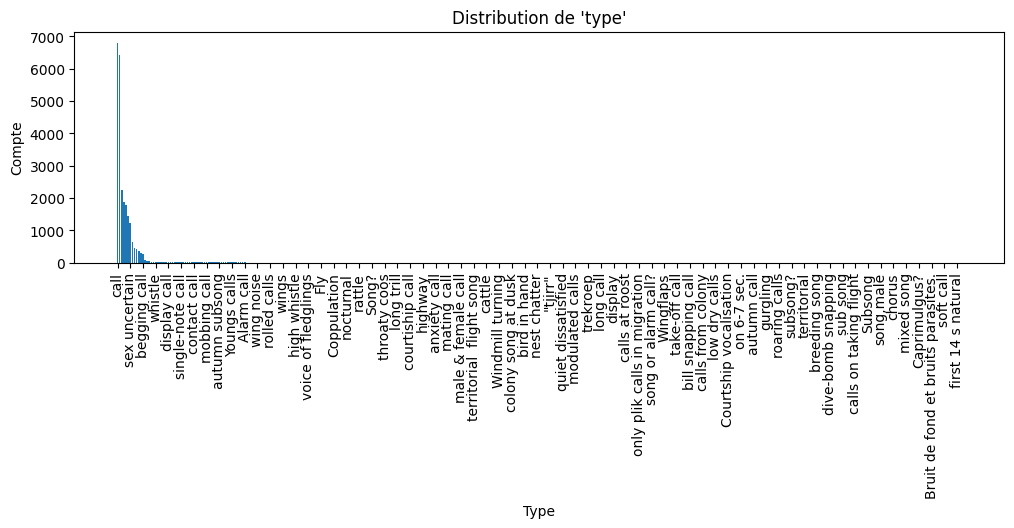

In [11]:
#
# examiner la distribution dans type
#
from itertools import islice

# calculer histogram
def type_histogram(types_, hist_dict):
    for t in types_:
        if t in hist_dict:
            hist_dict[t] += 1
        else:
            hist_dict[t] = 1

hist_dict = {}
raw_df["type"].apply(type_histogram, args=(hist_dict,))

# convertir en Series pandas (simplifie extraction statistiques)
hist_df =  pd.Series(data=hist_dict.values(), index=hist_dict.keys())

# afficher quelques stats
print("Stat. generale pour 'type'")
display(hist_df.describe().to_frame().T)

# afficher histogramme - ne garder que quelques lables car 
# il n'y en a trop pour etre visialise
count = len(hist_dict)

# afichage partiel des labels sur axe des x
# diagrame affiche tout par contre
step = 6

sorted_hist = sorted(hist_dict.items(), key=lambda x: x[1], reverse=True)
sorted_hist = {k:v for k, v in sorted_hist}

plt.figure(figsize=(12, 3))
plt.bar([i for i in range(count)], sorted_hist.values())

plt.gca().set_xticks([i for i in range(0, count, step)])
plt.gca().set_xticklabels([k for k in islice(sorted_hist.keys(), 0, count, step)], rotation=90)

plt.xlabel("Type")
plt.ylabel("Compte")
plt.title("Distribution de 'type'")
plt.show()

<div class="answer">

*  **type** a 399 modalités.
* La grande majorité des modalités se retrouvent dans 1 ou 2 fichiers.
* Un examen visuel sommaire du texte repésentant les modalités montrent qu'il faudrait un effort non négligeable pour l'inclure dans une classification. Ex: call, Song?, on 6-7 sec, highway.
* Bien qu'intéressant, semble avoir peu de pouvoir discrimant pour simplifier le projet, on rejette.

In [12]:
#
# examiner rating
#
print("rating est de type qualitatif - attendu discret selon description fournie sur Kaggle")

rating_df = raw_df["rating"].unique()
rating_df.sort()
print( "Modalités:", rating_df )

rating est de type qualitatif - attendu discret selon description fournie sur Kaggle
Modalités: [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5. ]


<div class="answer">
    
**En somme:**

* 16941 échantillons
* 12 variables. Selon les informations trouvées via l'url  et un examin visuel, les variables intéressantes semblent à prime abord:
    - **primary_label**: Identification de l'oiseau.
    - **latitude** & **longitude**: Coordonnés de l'enregistrement audio (gardé pour usage éventuel).
    - **filename**: Nom du fichier audio.
    - **url**: url sur informations complémentaires. Bien qu'utile, jugé non nécessaire puisque audio est deja présent dans les données etpeut être reconstruit à partir de primary_label.
    - **common_name**: Utile pour interprétation des résultats bien que non nécessaire.
    - **rating**: Evaluation de la qualité des fichiers audio. Pourrait etre utile pour filtrer davantage.
* Les variables sont en fait des fichiers audio augmentées avec les latitudes & longitudes (données de type quantitative) et quelques metadata (donnees de type qualitative)
* La variable cible est de type qualitative.

In [13]:
#
# ne garder que les attributs d'interets
#
data_df = raw_df[[
    "common_name",
    "primary_label", 
    "latitude", 
    "longitude", 
    "rating", 
    "filename"
]]
print("Attributs d'interet")
display(data_df.head())

Attributs d'interet


,common_name,primary_label,latitude,longitude,rating,filename
0,African Bare-eyed Thrush,abethr1,4.3906,38.2788,4.0,abethr1/XC128013.ogg
1,African Bare-eyed Thrush,abethr1,-2.9524,38.2921,3.5,abethr1/XC363501.ogg
2,African Bare-eyed Thrush,abethr1,-2.9524,38.2921,3.5,abethr1/XC363502.ogg
3,African Bare-eyed Thrush,abethr1,-2.9524,38.2921,5.0,abethr1/XC363503.ogg
4,African Bare-eyed Thrush,abethr1,-2.9524,38.2921,4.5,abethr1/XC363504.ogg


In [14]:
#
# explorer les valeurs manquantes
#
na_indices = data_df.isna()
na_rows = na_indices.any(axis=1)
na_num = na_rows.sum()

print(f"Quantité de valeurs manquantes: {na_num} ({na_num / data_df.shape[0] % 100:0.2f}%)")

print("Quelques valeurs manquantes")
display(data_df[na_rows].head())

Quantité de valeurs manquantes: 227 (0.01%)
Quelques valeurs manquantes


,common_name,primary_label,latitude,longitude,rating,filename
10,African Bare-eyed Thrush,abethr1,NaN,NaN,4.0,abethr1/XC585802.ogg
220,African Emerald Cuckoo,afecuc1,NaN,NaN,2.5,afecuc1/XC118454.ogg
913,Barn Swallow,barswa,NaN,NaN,1.0,barswa/XC169360.ogg
914,Barn Swallow,barswa,NaN,NaN,1.0,barswa/XC171221.ogg
916,Barn Swallow,barswa,NaN,NaN,3.0,barswa/XC171624.ogg


<div class="answer">

* Inspection dans .csv source montre bien que les valeurs sont manquantes.
* Comme il n'y en a peu, on les enlèves.

In [15]:
#
# Enlever NA
#
print("Shape avant:", data_df.shape)
valid_data_df = data_df[~na_rows]
print("Shape apres:", valid_data_df.shape)

Shape avant: (16941, 6)
Shape apres: (16714, 6)


In [16]:
#
# explorer doublons
#
dup_rows = valid_data_df.duplicated()
dup_num = dup_rows.sum()

print("Quantite de doublons:", dup_num)

Quantite de doublons: 0


<div class="answer">

* Pas de doublon.
* On extrait sampling rate et la durée des fichiers audio avant d'examiner les distributions. En effet, la solution envisagée risque d'utiliser des segments audios ce qui affecte les distributions.

In [17]:
# extraire sampling rate et duree des fichiers audios
# les resultats sont cacher; mettre FORCE_PROCESS_AUDIO_STATS a True pour recalculer
FORCE_PROCESS_AUDIO_STATS = False

filename = Path.joinpath(config.paths.DATA_RAW_DIR, "data_extended.csv")

def get_samplingrate_numsamples(config, filename):
    f = config.get_audio_filename(filename)

    # tester audioread vs librosa pour lecture
    # techniquement, pas besoin de tout loader pour avoir infos voulue
    # conclusion: aucune difference en terme de temps de loading MAIS
    #             sampling rate est different
    # note: revision de la docmontre que sr=None retourne sampling rate du fichier
    y, sr = rosa.load(f, sr=None)
    return sr, len(y), int(len(y) / sr * 1000)

if FORCE_PROCESS_AUDIO_STATS or not Path(filename).is_file():
    from ffury.misc.concurrent import (
        create_dask_local_client,
        parallel_for
    )

    selected_audio = valid_data_df[:]

    def process_batch(config, batch):
        data = []
        for index, (common_name, primary_label, latitude, longitude, rating, filename) in batch:
            sr, num_samples, duration_ms = get_samplingrate_numsamples(config, filename)
            data.append([common_name,
                         primary_label,
                         latitude,
                         longitude,
                         rating,
                         filename,
                         sr,
                         num_samples,
                         duration_ms])
        return data

    def batch_done(data, progress, accum):
        accum.extend(data)
        progress.update(len(data))

    audio_data = []
    total = len(selected_audio)
    with create_dask_local_client(memory_limit="2GB") as client:
        with tqdm(total=total) as progress:
            parallel_for(selected_audio.iterrows(),
                         process_batch,
                         config,
                         task_completed=lambda r: batch_done(r, progress, audio_data),
                         chunk_size=10,
                         client=client)

    extended_data_df = pd.DataFrame(data=audio_data,
                                    columns=["common_name",
                                             "primary_label",
                                             "latitude",
                                             "longitude",
                                             "rating",
                                             "filename",
                                             "sr",
                                             "num_samples",
                                             "duration_ms"])
    extended_data_df.to_csv(filename, 
                            index=False)
    print("Sauvegarde", filename)
else:
    extended_data_df = pd.read_csv(filename)
    print("Réutilise", filename)

  0%|          | 0/16714 [00:00<?, ?it/s]

Sauvegarde /Users/jfgagnon/Projects/FeatheredFury/data/raw/data_extended.csv


In [18]:
# valider l'etape precedente 
# relire 100 fichiers choisi au hasard et valider duration et sampling rate
if False:
    for i in np.random.randint(0, len(extended_data_df), 100):
        row = extended_data_df.iloc[i]
        sr, num_samples, duration_ms = get_samplingrate_numsamples(config, row["filename"])
        assert sr == row["sr"], f"i: {row['filename']} - {sr} vs {row['sr']}"
        assert num_samples == row["num_samples"], f"i: {row['filename']} - {num_samples} vs {row['nm_samples']}"

        assert duration_ms == row["duration_ms"], f"i: {row['filename']} - {duration_ms} vs {row['duration_ms']}"

    print("Validation SR et duration: PASSED")

Nombre d'espèces: 264


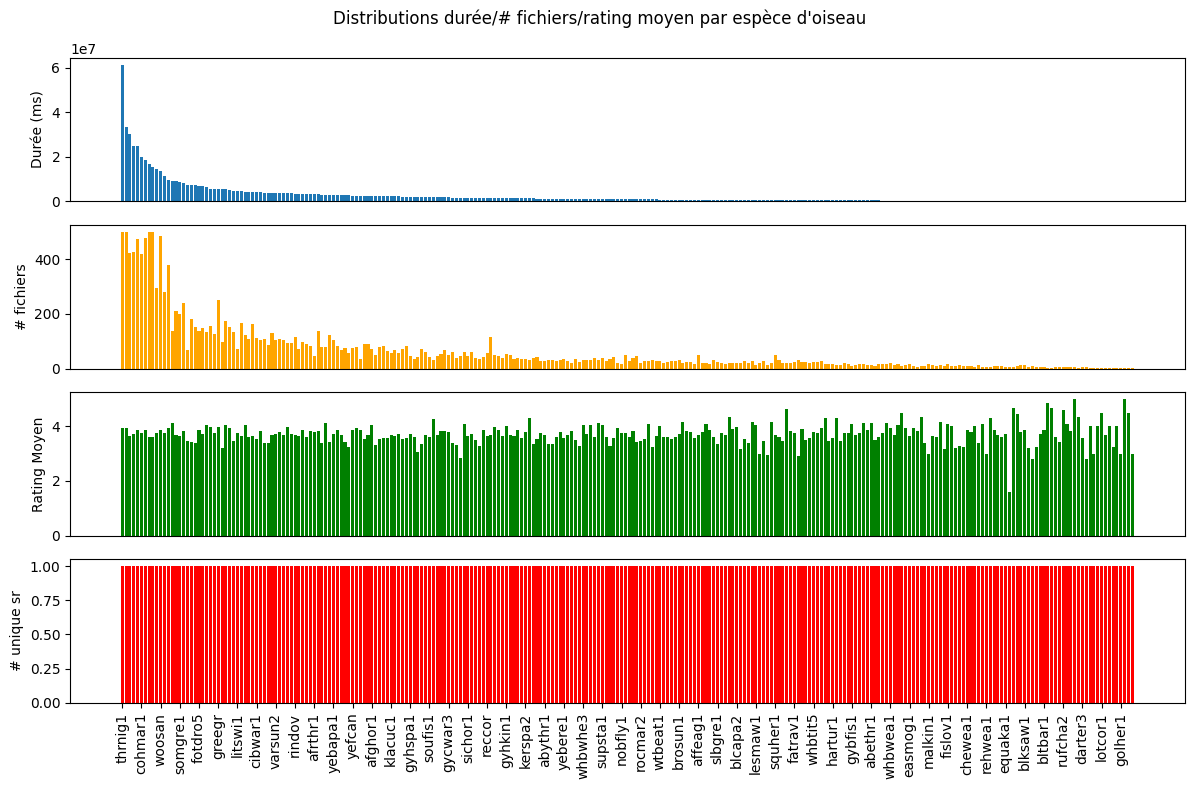

In [19]:
# examiner distributions primary_label (espece)
#
unique_bird = extended_data_df.groupby(by="primary_label")
unique_bird_count = len(unique_bird)
print("Nombre d'espèces:", unique_bird_count)

unique_bird_dist = unique_bird.agg({"duration_ms": ["sum", "count"], 
                                    "rating": "mean",
                                    "sr": "nunique"})
unique_bird_dist = unique_bird_dist.sort_values(by=("duration_ms", "sum"), 
                                                ascending=False)

total_duration = unique_bird_dist[("duration_ms", "sum")]
num_samples = unique_bird_dist[("duration_ms", "count")]
mean_rating = unique_bird_dist[("rating", "mean")]
sr_count = unique_bird_dist[("sr", "nunique")]

STEP = 5
WIDTH = 2

dist_range = range(unique_bird_count)
dist_range_step = range(0, unique_bird_count, STEP)

indices = [i for i in dist_range]
indices_step = [i for i in dist_range_step]

plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.bar(indices,
        total_duration.iloc[indices])
plt.ylabel("Durée (ms)")
plt.tick_params(axis="x",
                which="both",
                bottom=False,
                top=False,
                labelbottom=False)

plt.subplot(412)
plt.bar(indices,
        num_samples.iloc[indices],
        color="orange")
plt.ylabel("# fichiers")
plt.tick_params(axis="x",
                which="both",
                bottom=False,
                top=False,
                labelbottom=False)

plt.subplot(413)
plt.bar(indices,
        mean_rating.iloc[indices],
        color="green")
plt.ylabel("Rating Moyen")
plt.tick_params(axis="x",
                which="both",
                bottom=False,
                top=False,
                labelbottom=False)

plt.subplot(414)
plt.bar(indices,
        sr_count.iloc[indices],
        color="red")
plt.ylabel("# unique sr")

plt.gca().set_xticks(indices_step)
plt.gca().set_xticklabels([unique_bird_dist.index[i] for i in indices_step], rotation=90)

plt.suptitle("Distributions durée/# fichiers/rating moyen par espèce d'oiseau")
plt.tight_layout()
plt.show()

In [20]:
# stats sommaire par espece
#
display(unique_bird_dist.describe().T)
print("Sampling rate:", extended_data_df["sr"].unique())

count          mean           std          min  \
duration_ms sum      264.0  2.592551e+06  5.703940e+06  7752.000000   
            count    264.0  6.331061e+01  9.699807e+01     1.000000   
rating      mean     264.0  3.723870e+00  3.785519e-01     1.583333   
sr          nunique  264.0  1.000000e+00  0.000000e+00     1.000000   

                               25%            50%           75%         max  
duration_ms sum      383005.000000  960311.000000  2.333874e+06  61406554.0  
            count        14.000000      29.500000  7.025000e+01       500.0  
rating      mean          3.555556       3.711982  3.923789e+00         5.0  
sr          nunique       1.000000       1.000000  1.000000e+00         1.0

Sampling rate: [32000]


<div class="answer">

* 264 correspond au nombre d'espèces attendu selon description du dataset.
* 1 seul sampling rate.
* **rating** semble couvrir uniformement toutes les espèces.
* Distributions durée et nombre de fichiers sont très mal balancées.
* La partie gauche de la distribution de la durée est assez differente de celle du nombre de fichiers.
* Il y a beaucoup d'espèce avec peu de fichiers.

Regardons la distribution des durées.

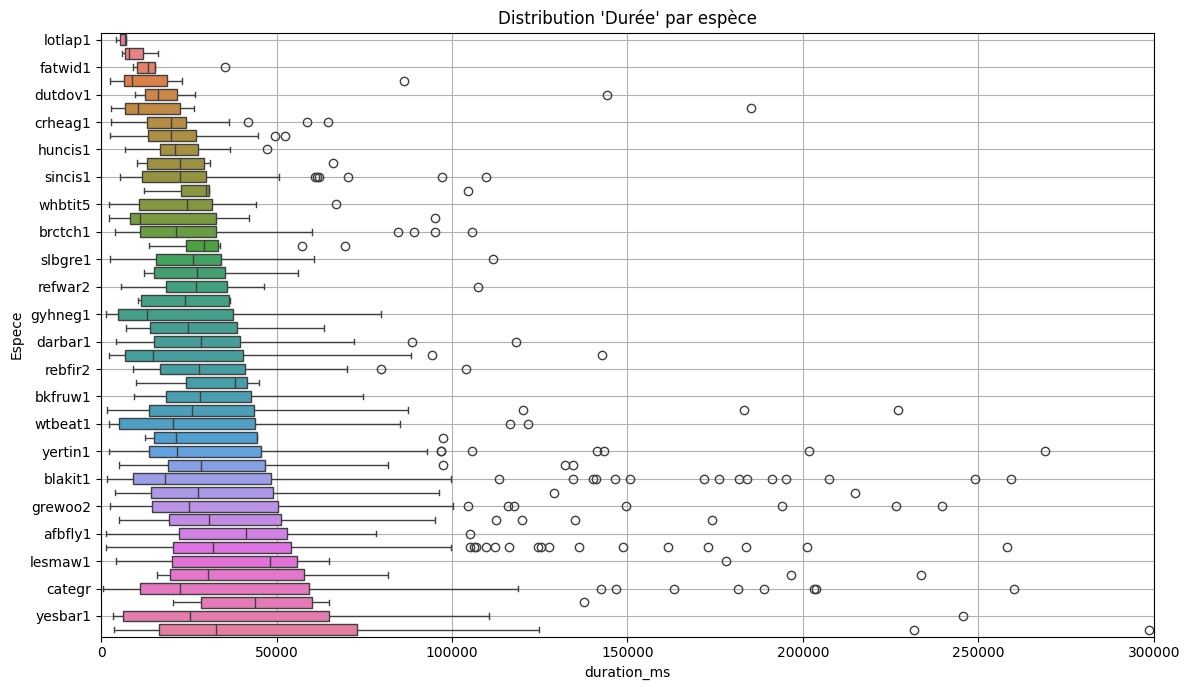

Les espèces ne sont pas toutes présentées dans le graph pour préserver la lisibilité.


In [21]:
# distributions des durees par espece
#
duration_dict = {}
duration_sorting_dict = {}

for i, g in enumerate(unique_bird.groups):
    data = unique_bird.get_group(g)
    group = str(g)
    duration = data["duration_ms"]
    duration_total = duration.sum()
    duration_dict[group] = duration
    duration_sorting_dict[group] = duration.quantile(0.75)

sorted_keys = list(duration_sorting_dict.keys())
sorted_keys = sorted(sorted_keys, key=lambda k: duration_sorting_dict[k])

STEP = 6

from collections import OrderedDict
ordered_duration_dict = OrderedDict((k, duration_dict[k]) for k in sorted_keys[::STEP])

plt.figure(figsize=(12, 7))
sns.boxplot(ordered_duration_dict, orient="h", ax=plt.gca())
plt.grid()
plt.title("Distribution 'Durée' par espèce")
plt.xlabel("duration_ms")
plt.ylabel("Espece")

STEP = 2

keys_ = list(ordered_duration_dict.keys())

plt.gca().set_yticks([s for s in range(0, len(keys_), STEP)])
plt.gca().set_yticklabels([k for k in keys_[::STEP]])

# limiter le range de visualisation pour mieux voir distributions
plt.xlim(0, 300_000)
plt.tight_layout()
plt.show()

print("Les espèces ne sont pas toutes présentées dans le graph pour préserver la lisibilité.")

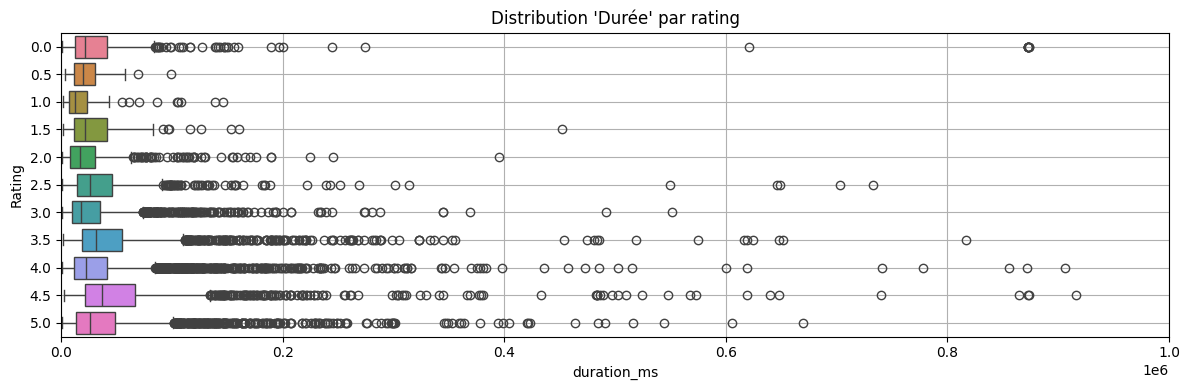

Stats sommaire par rating


rating                  0.0       0.5        1.0        1.5        2.0  \
duration_ms Q1     12255.00  11245.00    6974.00   11768.00    8262.00   
            Q2     21174.50  19761.50   12042.00   21655.00   16507.50   
            Q3     41086.25  30099.25   23031.75   40918.50   30739.50   
            Mean   46267.21  25171.08   21926.02   33268.91   28368.33   
            Min      940.00   3082.00    1253.00    1752.00     966.00   
            Max   873299.00  99360.00  145893.00  452022.00  395088.00   

rating                   2.5       3.0         3.5         4.0        4.5  \
duration_ms Q1      14347.50    9456.0    18513.50    11781.00    21786.0   
            Q2      26004.50   18124.0    31359.50    22099.00    37041.0   
            Q3      45432.00   35088.5    55222.50    40946.50    66670.5   
            Mean    41452.32   29204.1    51366.83    36310.94    63397.2   
            Min       864.00     816.0     1253.00      548.00     2280.0   
            Max   2043167.00  551262.0  2373528.00  1787846.00  1380022.0   

rating                   5.0  
duration_ms Q1      12936.00  
            Q2      26220.00  
            Q3      48364.50  
            Mean    40563.42  
            Min       792.00  
            Max   1144032.00

In [22]:
# distributions des durees par rating
#
ratings = extended_data_df.groupby(by="rating")

duration_dict = {}
duration_sorting_dict = {}

for i, g in enumerate(ratings.groups):
    duration_dict[str(g)] = ratings.get_group(g)["duration_ms"]

plt.figure(figsize=(12, 4))
sns.boxplot(duration_dict, orient="h", ax=plt.gca())
plt.grid()
plt.title("Distribution 'Durée' par rating")
plt.xlabel("duration_ms")
plt.ylabel("Rating")

# limiter le range de visualisation pour mieux voir distributions
plt.xlim(0, 1000_000)
plt.tight_layout()
plt.show()

# stats generales par ratings
#
groups = ratings.agg({"duration_ms": [("Q1", lambda x: x.quantile(0.25)),
                                      ("Q2", lambda x: x.quantile(0.50)),
                                      ("Q3", lambda x: x.quantile(0.75)),
                                      ("Mean", lambda x: x.mean()),
                                      ("Min", lambda x: x.min()),
                                      ("Max", lambda x: x.max())]})
print("Stats sommaire par rating")
display(groups.T.round(2))

<div class="answer">

* Les distributions de durée par espèce sont en générale très diférentes.
* Les distributions de durée par **ratings**, non obstant les outliers, semblent plus similaires que celles par espèce.
* On remarque la présence de clips audio très long. Selon la description du dataset, la capture s'effectue dans des conditions réelles. On pourrait alors croire que plus la durée est grande, plus les clips sont susceptible de contenir des éléments parasites rendant l'identification difficile. Cepandant, **rating** semble suggérer, en regardant les outliers de durée, que les long clips sont mieux cotés (**rating** > 2.5 semblent avoir plus d'outliers).

Bien que suggestif, écoutons quelques clips pour évaluer **rating**.

In [23]:
def clip_in_rating(min_rating, max_rating, min_duration=None, max_duration=None, data_df=extended_data_df):
    r = data_df["rating"] >= min_rating
    r = r & (data_df["rating"] <= max_rating)
    if not min_duration is None:
        r = r & (data_df["duration_ms"] >= min_duration)
    if not max_duration is None:
        r = r & (data_df["duration_ms"] <= max_duration)
    return data_df[r]

def log_clip_in_rating(min_rating, max_rating, min_duration=None, max_duration=None, data_df=extended_data_df):
    r = clip_in_rating(min_rating, 
                       max_rating, 
                       min_duration=min_duration, 
                       max_duration=max_duration, 
                       data_df=data_df)
    msg = f"Nombre de clips avec rating [{min_rating}, {max_rating}]"
    if not min_duration is None:
        msg += f" et durée >= {min_duration}"
    if not max_duration is None:
        msg += f" et durée <= {max_duration}"
    print(msg, ":", r.shape[0], "-- durée totale:", round(r["duration_ms"].sum() / 3600000, 2), "heure(s)")
    return r

def sample(data_df, count):
    count = min(data_df.shape[0], count)
    return data_df.sample(n=count, axis=0, replace=False)

viz_data = log_clip_in_rating(2.5, 
                              5.0, 
                              min_duration=3_000,
                              max_duration=30_000)

Nombre de clips avec rating [2.5, 5.0] et durée >= 3000 et durée <= 30000 : 8569 -- durée totale: 37.23 heure(s)


In [24]:
from copy import copy
from IPython.display import Audio
from ipywidgets import Output, Layout, VBox, HBox, HTML

def melspectrogram(y, sr, **kwargs):
    # besoin de passer certains parametres entre melspectrogram()
    # et specshow() pour matcher timeline
    mel_kwargs = copy(kwargs)
    display_kwargs = {}

    if "n_fft" in kwargs:
        mel_kwargs["n_fft"] = math.ceil(kwargs["n_fft"] * sr)
        display_kwargs["n_fft"] = mel_kwargs["n_fft"]

    if "hop_length" in kwargs:
        mel_kwargs["hop_length"] = math.ceil(kwargs["hop_length"] * sr)
        display_kwargs["hop_length"] = mel_kwargs["hop_length"]

    S = rosa.feature.melspectrogram(y=y, sr=sr, power=2,  **mel_kwargs)
    S_db = rosa.power_to_db(S, ref=np.max)

    return S_db, display_kwargs

def get_display_outputs(index, data_df, figsize=None, **melspectrogram_kwargs):
    filename = data_df.loc[index, "filename"]
    filename = config.get_audio_filename(filename)
    y, sr = rosa.load(filename)

    waveform = Output()
    with waveform:
        fig = plt.figure(figsize=figsize)
        rosa.display.waveshow(y,
                              sr=sr,
                              ax=plt.gca())
        plt.xlabel("")
        plt.close()

        display(fig)

    spectrogram = Output()
    with spectrogram:
        fig = plt.figure(figsize=figsize)

        S_db, display_kwargs = melspectrogram(y, sr, **melspectrogram_kwargs)
        rosa.display.specshow(S_db,
                              x_axis='time',
                              y_axis='mel',
                              sr=sr,
                              ax=plt.gca(),
                              **display_kwargs)
        plt.xlabel("")
        plt.close()

        display(fig)

    player = Output()
    with player:
        display(Audio(data=y, rate=sr))

    header = Output()
    with header:
        filename = data_df.loc[index, 'filename']
        rating = data_df.loc[index, 'rating']
        html = HTML(f"{filename} - index {index} - rating {rating}")
        display(html)

    hb = HBox([waveform, spectrogram, player], 
              layout=Layout(width="100%", align_items="center"))

    vb = VBox([header, hb], 
              layout=Layout(height="100%", align_items="center", padding="10px 0 0 0"))

    return vb

def visualize_audio_from_extended_df(indices, figsize=None, **melspectrogram_kwargs):
    rows = []
    for index in indices:
        row = get_display_outputs(index,
                                  extended_data_df,
                                  figsize=figsize,
                                  **melspectrogram_kwargs)
        rows.append(row)
    display(VBox(rows))

def get_indices(filenames):
    ids = []
    for f in filenames:
        index = extended_data_df["filename"] == f
        ids.extend( extended_data_df[index].index.values )
    return ids

if False:
    # visualization random de viz_data
    ids = sample(viz_data, 10)
    ids = ids.index.tolist()
else:
    # exemple de "mauvaise" qualite
    exemples = ["spmthr1/XC559589.ogg",
                "colsun2/XC188947.ogg",
                "eubeat1/XC597723.ogg",
                "didcuc1/XC435836.ogg",
                "blbpuf2/XC317680.ogg",
                "malkin1/XC462417.ogg"]
    ids = get_indices(exemples)

#
# aide melspectrogram: https://tinyurl.com/3vf92xvx
#
STFT_FRAME_SIZE_MS = 100 / 1000 # ms
STFT_WINDOW_SIZE_MS = 2 * STFT_FRAME_SIZE_MS # ms

print("Clips de 'mauvaise' qualité")
visualize_audio_from_extended_df(ids,
                                 figsize=(10, 4),
                                 n_fft=STFT_WINDOW_SIZE_MS, # ms
                                 hop_length=STFT_FRAME_SIZE_MS, # ms
                                 n_mels=128,
                                 fmin=0,
                                 fmax=8192)

Clips de 'mauvaise' qualité


In [27]:
# mis en commentaire pour economiser espace disque
# reactiver pour visualiser
#
if True:
    if False:
        long_clips = log_clip_in_rating(3.5,
                                        5.0,
                                        min_duration=1000_000)
        ids = sample(long_clips, 2)
        ids = ids.index.tolist()
    else:
        exemples = ["wlwwar/XC479013.ogg"]
        ids = get_indices(exemples)

    # log_clip_in_rating(0.0, 2.5);

    print("Clips de longue durée")
    visualize_audio_from_extended_df(ids,
                                     figsize=(10, 4),
                                     n_fft=STFT_WINDOW_SIZE_MS, # ms
                                     hop_length=STFT_FRAME_SIZE_MS, # ms
                                     n_mels=128,
                                     fmin=0,
                                     fmax=8192)

Clips de longue durée


<div class="answer">

* Bien que non exhaustif, les échantillons précédants suggère que **rating** est corrélé à la capacité d'identification des oiseaux. A savoir, enregistrement de bonne qualité, chant oiseau bien défini. Nous garderons **rating** >= 4.0.
* Il est plus difficile de trancher sur la durée. Un modèle de haute qualité devrait pouvoir gérer ces clips mais dans un but de simplification, les clips de plus de 100 secondes seront enlevés. En effet, ces clips ont une plus grande chance d'avoir des situations difficile à gérer ; très long silences, bruits soudains, etc. Les clips couts Les clips trop courts ont possiblement moins de contexte à offrir bien qu'étant probablement plus simple. La literature semble suggérer des segments audio d'au moins 3 secondes. Nous gardons 10 secondes afin d'avoir un peu plus de diversités auditives.
* Dans un but de simplification, nous garderons les 5 espèces ayant la plus longue durée d'enregistrement.
* Le débalancement sera adressé par un resampling détaillé dans une autre étape.
* Noter que notre manque de connaissance dans le domaine ne nous permets pas d'aller au dela de ces constats.

In [26]:
# filtrer le data d'interet
#
NUM_SPECIES = 5
RATING_MIN = 4.0
DURATION_MIN = 10_000.0
DURATION_MAX = 100_000.0

filtered_df = (extended_data_df["rating"] >= RATING_MIN) & \
              (extended_data_df["duration_ms"] >= DURATION_MIN) & \
              (extended_data_df["duration_ms"] <= DURATION_MAX)
filtered_df = extended_data_df[filtered_df]

topmost_sample_species = filtered_df.groupby(by="primary_label") \
                                    .agg({"duration_ms": ["sum"]}) \
                                    .nlargest(NUM_SPECIES, ("duration_ms", "sum"))
topmost_sample_species = set(topmost_sample_species.index)

final_data_df = filtered_df["primary_label"].apply(lambda x: x in topmost_sample_species)
final_data_df = filtered_df[final_data_df].copy()
final_data_df.drop(columns=["rating", "sr", "num_samples"], inplace=True, errors="ignore")

print("# elements avant filtrage:", extended_data_df.shape[0])
print("# elements apres filtrage:", final_data_df.shape[0])
print()
print("Attributs retenus:\n", final_data_df.columns.values)

# sauvegarder premiere etape d'exploration
total_duration = final_data_df["duration_ms"].sum()

print()

hours = total_duration / 3600_000
minutes, hours = math.modf(hours)
seconds, minutes = math.modf(minutes * 60)
seconds = seconds * 60

hours = int(hours)
minutes = int(minutes)
seconds = int(seconds)

print(f"Duree total apres filtrage:  {hours}h {minutes}m {seconds}s")

print()

# sauvegarde du traitement
filename = config.get_csv_filename(DatasetType.EXPLORED)
print("Sauvegarde de l'exploration:", filename)
final_data_df.to_csv(filename, index=False)

# elements avant filtrage: 16714
# elements apres filtrage: 1104

Attributs retenus:
 ['common_name' 'primary_label' 'latitude' 'longitude' 'filename'
 'duration_ms']

Duree total apres filtrage:  12h 16m 29s

Sauvegarde de l'exploration: /Users/jfgagnon/Projects/FeatheredFury/data/data_explored.csv
